<a href="https://colab.research.google.com/github/Piotr1709/lecture1/blob/main/Rak.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
y = data.target #list(data.target_names)
X = data.data #data.feature_names

In [11]:
X.shape
sum(y)

np.int64(357)

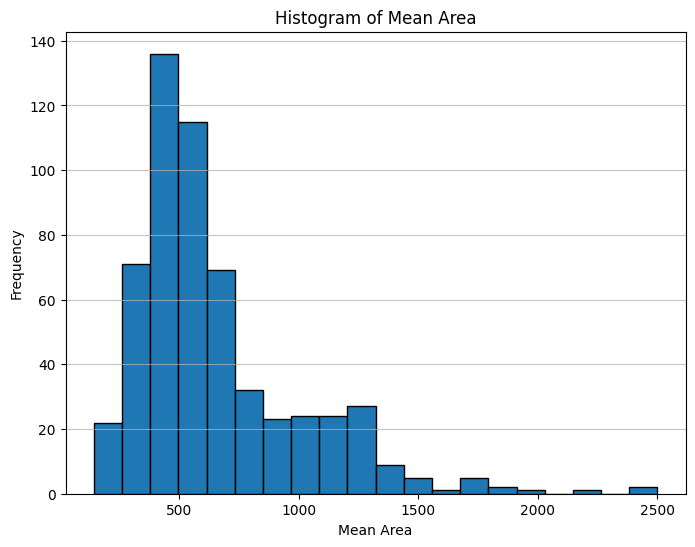

In [12]:
import matplotlib.pyplot as plt
feature_names = data.feature_names
try:
    mean_area_idx = list(feature_names).index('mean area')
    mean_area_data = X[:, mean_area_idx]

    plt.figure(figsize=(8, 6))
    plt.hist(mean_area_data, bins=20, edgecolor='black')
    plt.title('Histogram of Mean Area')
    plt.xlabel('Mean Area')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()
except ValueError:
    print("'mean area' feature not found in the dataset. Available features are:")
    for i, name in enumerate(feature_names):
        print(f"{i}: {name}")

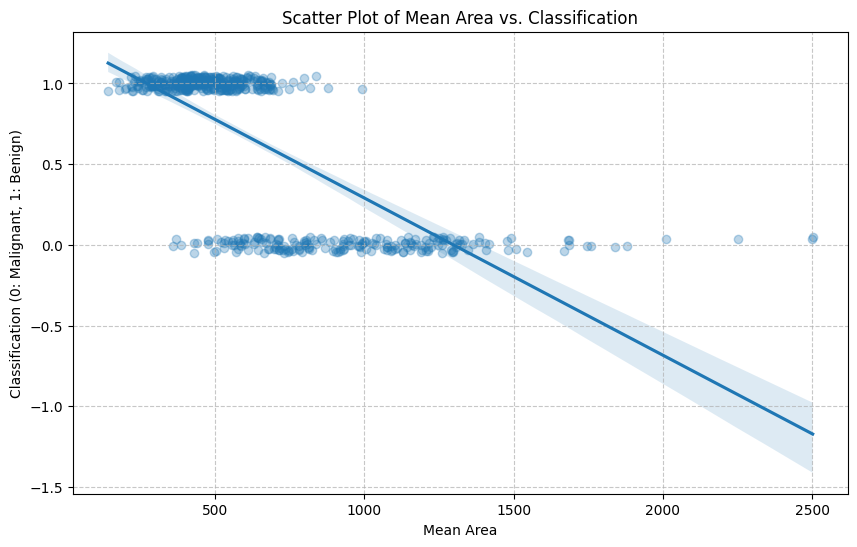

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Mean Area': mean_area_data,
    'Classification': y
})

plt.figure(figsize=(10, 6))
sns.regplot(x='Mean Area', y='Classification', data=plot_df, x_jitter=0.5, y_jitter=0.05, scatter_kws={'alpha':0.3})
plt.title('Scatter Plot of Mean Area vs. Classification')
plt.xlabel('Mean Area')
plt.ylabel('Classification (0: Malignant, 1: Benign)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled=scaler.fit_transform(X)
print(X_scaled[:5])

[[ 1.09706398e+00 -2.07333501e+00  1.26993369e+00  9.84374905e-01
   1.56846633e+00  3.28351467e+00  2.65287398e+00  2.53247522e+00
   2.21751501e+00  2.25574689e+00  2.48973393e+00 -5.65265059e-01
   2.83303087e+00  2.48757756e+00 -2.14001647e-01  1.31686157e+00
   7.24026158e-01  6.60819941e-01  1.14875667e+00  9.07083081e-01
   1.88668963e+00 -1.35929347e+00  2.30360062e+00  2.00123749e+00
   1.30768627e+00  2.61666502e+00  2.10952635e+00  2.29607613e+00
   2.75062224e+00  1.93701461e+00]
 [ 1.82982061e+00 -3.53632408e-01  1.68595471e+00  1.90870825e+00
  -8.26962447e-01 -4.87071673e-01 -2.38458552e-02  5.48144156e-01
   1.39236330e-03 -8.68652457e-01  4.99254601e-01 -8.76243603e-01
   2.63326966e-01  7.42401948e-01 -6.05350847e-01 -6.92926270e-01
  -4.40780058e-01  2.60162067e-01 -8.05450380e-01 -9.94437403e-02
   1.80592744e+00 -3.69203222e-01  1.53512599e+00  1.89048899e+00
  -3.75611957e-01 -4.30444219e-01 -1.46748968e-01  1.08708430e+00
  -2.43889668e-01  2.81189987e-01]
 [ 1.5

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
print({X_train.shape})
print({X_test.shape})
print({y_train.shape})
print({y_test.shape})

{(398, 30)}
{(171, 30)}
{(398,)}
{(171,)}


              precision    recall  f1-score   support

           0       0.97      0.98      0.98        63
           1       0.99      0.98      0.99       108

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



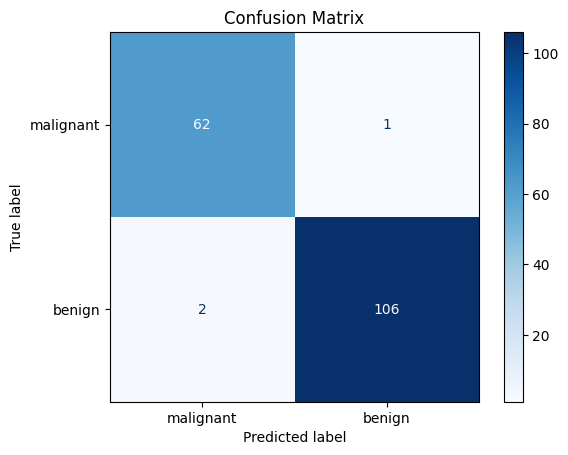

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


<Figure size 800x600 with 0 Axes>

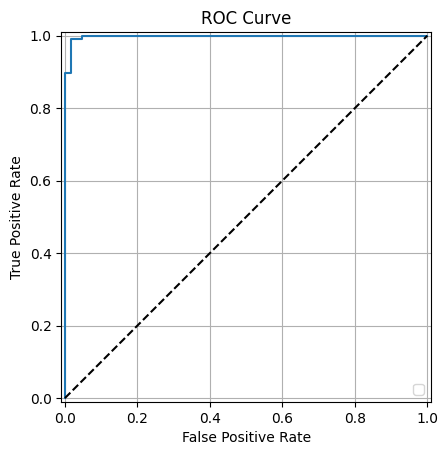

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay, roc_curve, classification_report
import matplotlib.pyplot as plt

model = LogisticRegression(random_state=42, solver='liblinear')
model.fit(X_train, y_train)
y_pred=model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]
print(classification_report(y_test,y_pred))
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr).plot()
plt.title('ROC Curve')
plt.plot([0, 1], [0, 1], 'k--') # Add diagonal line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.show()


KNN Classifier Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



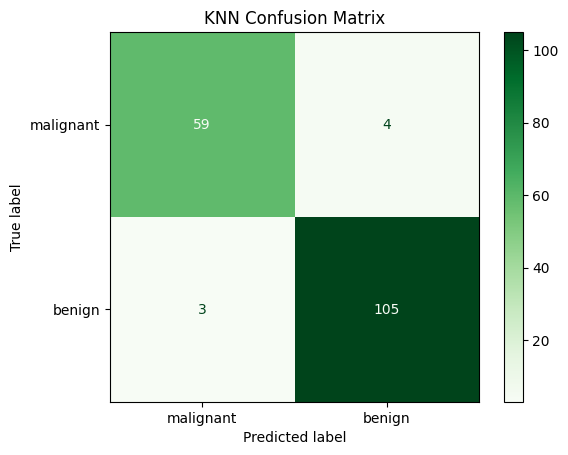

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


<Figure size 800x600 with 0 Axes>

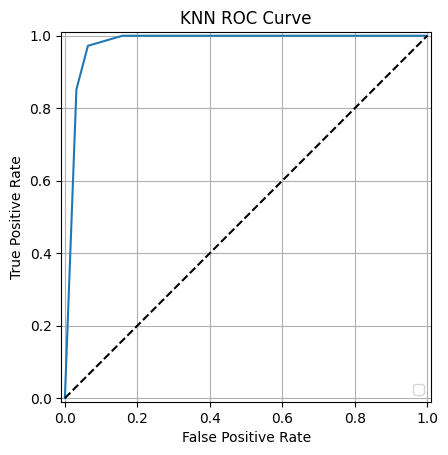

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay, roc_curve, classification_report
import matplotlib.pyplot as plt

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
y_proba_knn = knn_model.predict_proba(X_test)[:, 1]

print("\nKNN Classifier Report:")
print(classification_report(y_test, y_pred_knn))
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=data.target_names)
disp_knn.plot(cmap=plt.cm.Greens)
plt.title('KNN Confusion Matrix')
plt.show()

plt.figure(figsize=(8, 6))
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
roc_display_knn = RocCurveDisplay(fpr=fpr_knn, tpr=tpr_knn).plot()
plt.title('KNN ROC Curve')
plt.plot([0, 1], [0, 1], 'k--') # Add diagonal line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.show()


KNN Classifier Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



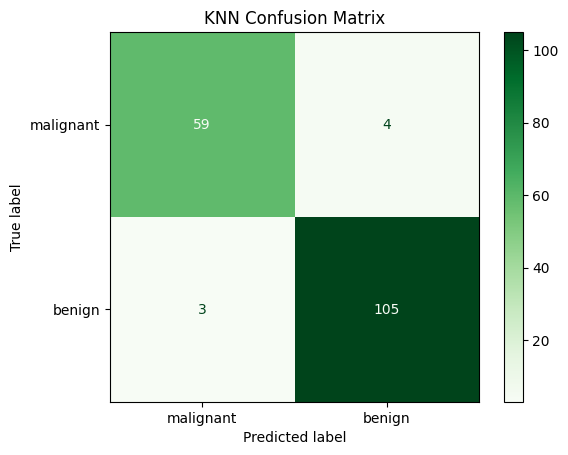

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


<Figure size 800x600 with 0 Axes>

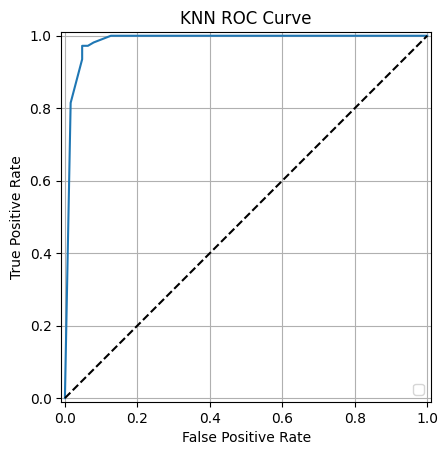

In [19]:
knn_model1 = KNeighborsClassifier(n_neighbors=7)
knn_model1.fit(X_train, y_train)

y_pred_knn1 = knn_model1.predict(X_test)
y_proba_knn1 = knn_model1.predict_proba(X_test)[:, 1]

print("\nKNN Classifier Report:")
print(classification_report(y_test, y_pred_knn1))
cm_knn = confusion_matrix(y_test, y_pred_knn1)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=data.target_names)
disp_knn.plot(cmap=plt.cm.Greens)
plt.title('KNN Confusion Matrix')
plt.show()

plt.figure(figsize=(8, 6))
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn1)
roc_display_knn = RocCurveDisplay(fpr=fpr_knn, tpr=tpr_knn).plot()
plt.title('KNN ROC Curve')
plt.plot([0, 1], [0, 1], 'k--') # Add diagonal line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.show()

Logistic Regression AUC: 0.9981
KNN Classifier AUC: 0.9777


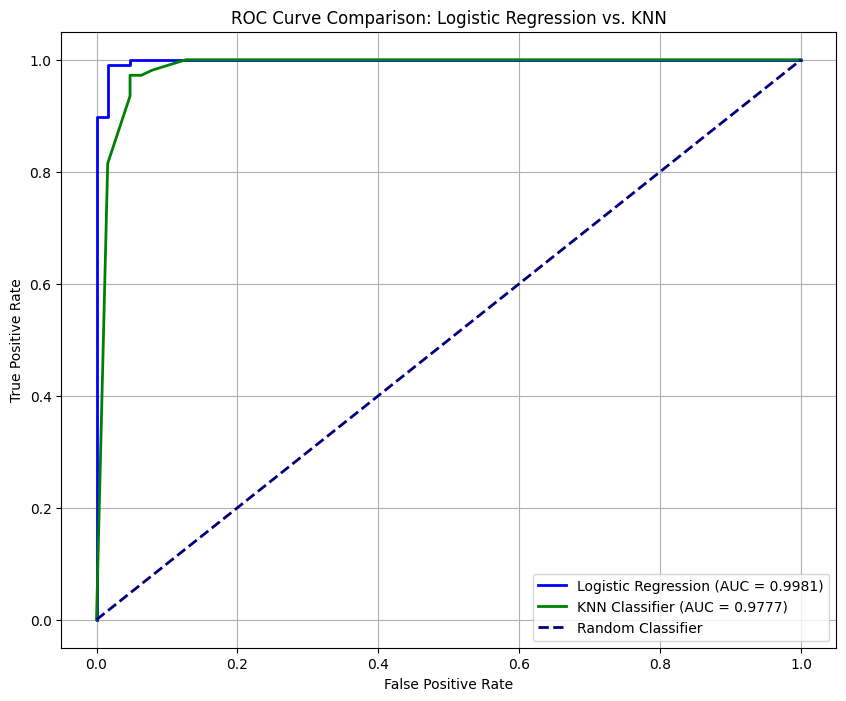

In [20]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

auc_lr = roc_auc_score(y_test, y_proba)

auc_knn = roc_auc_score(y_test, y_proba_knn)

print(f"Logistic Regression AUC: {auc_lr:.4f}")
print(f"KNN Classifier AUC: {auc_knn:.4f}")

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_knn, tpr_knn, color='green', lw=2, label=f'KNN Classifier (AUC = {auc_knn:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Logistic Regression vs. KNN')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


Decision Tree Classifier Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92        63
           1       0.97      0.94      0.95       108

    accuracy                           0.94       171
   macro avg       0.93      0.94      0.94       171
weighted avg       0.94      0.94      0.94       171



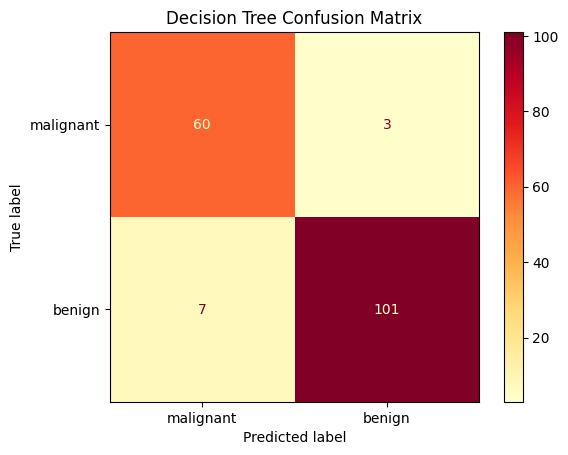

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


<Figure size 800x600 with 0 Axes>

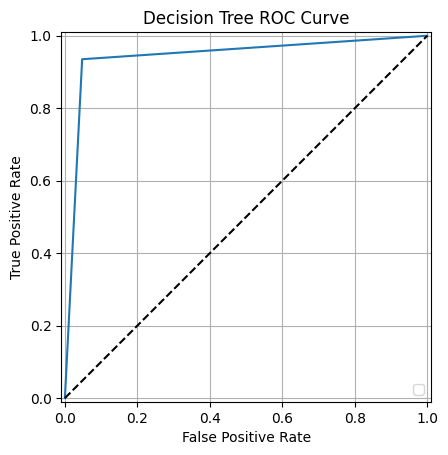

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay, roc_curve, classification_report
import matplotlib.pyplot as plt

y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

print("\nDecision Tree Classifier Report:")
print(classification_report(y_test, y_pred_dt))

cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=data.target_names)
disp_dt.plot(cmap=plt.cm.YlOrRd)
plt.title('Decision Tree Confusion Matrix')
plt.show()

plt.figure(figsize=(8, 6))
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
roc_display_dt = RocCurveDisplay(fpr=fpr_dt, tpr=tpr_dt).plot()
plt.title('Decision Tree ROC Curve')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.show()


Random Forest Classifier Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        63
           1       0.97      0.98      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



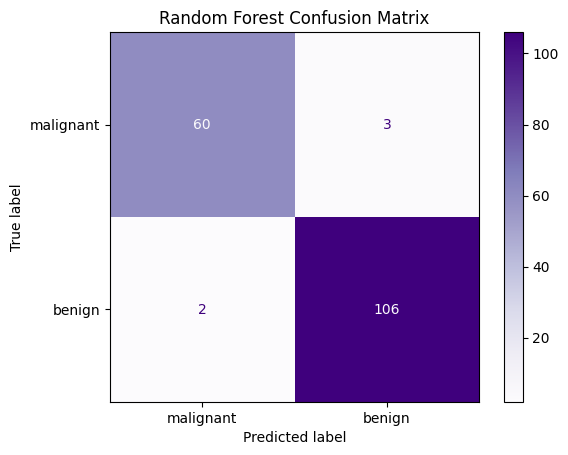

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


<Figure size 800x600 with 0 Axes>

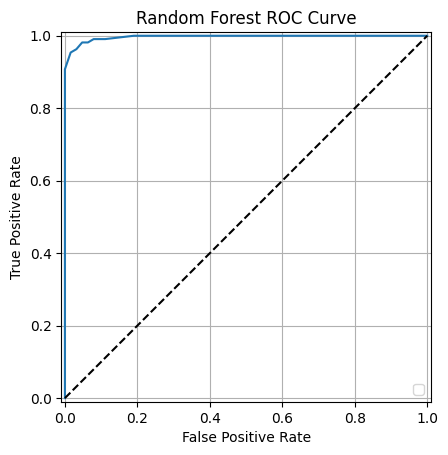

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay, roc_curve, classification_report
import matplotlib.pyplot as plt

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("\nRandom Forest Classifier Report:")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=data.target_names)
disp_rf.plot(cmap=plt.cm.Purples)
plt.title('Random Forest Confusion Matrix')
plt.show()

plt.figure(figsize=(8, 6))
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_display_rf = RocCurveDisplay(fpr=fpr_rf, tpr=tpr_rf).plot()
plt.title('Random Forest ROC Curve')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.show()

### Comparing Decision Tree and Random Forest Classifiers

Decision Tree AUC: 0.9438
Random Forest AUC: 0.9966


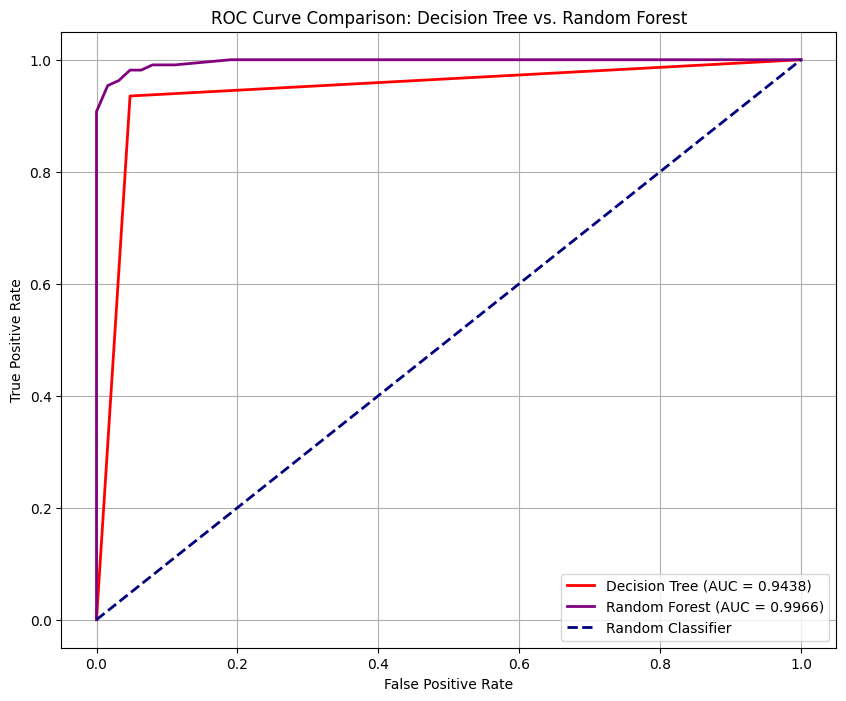

In [27]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

auc_dt = roc_auc_score(y_test, y_proba_dt)
auc_rf = roc_auc_score(y_test, y_proba_rf)

print(f"Decision Tree AUC: {auc_dt:.4f}")
print(f"Random Forest AUC: {auc_rf:.4f}")

plt.figure(figsize=(10, 8))
plt.plot(fpr_dt, tpr_dt, color='red', lw=2, label=f'Decision Tree (AUC = {auc_dt:.4f})')
plt.plot(fpr_rf, tpr_rf, color='purple', lw=2, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Decision Tree vs. Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

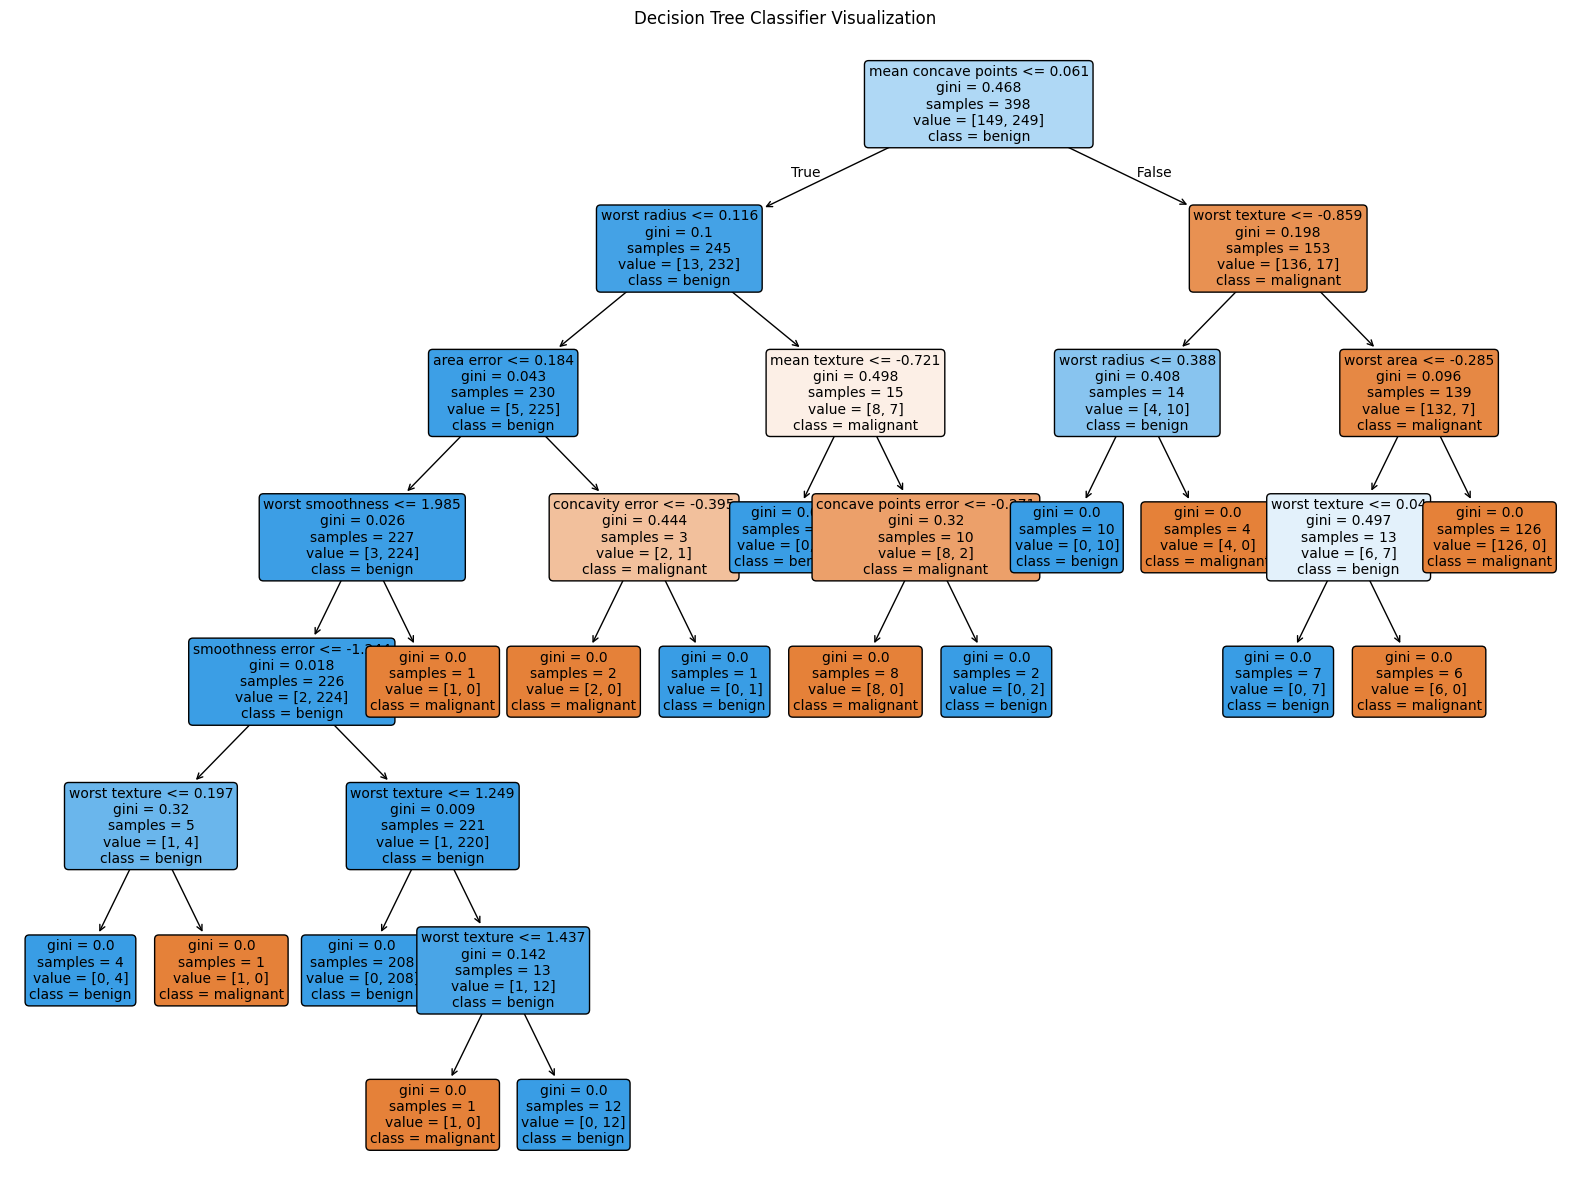

In [28]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 15))
plot_tree(dt_model, feature_names=feature_names, class_names=data.target_names, filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Classifier Visualization')
plt.show()


Gaussian Naive Bayes Classifier Report:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91        63
           1       0.94      0.95      0.95       108

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



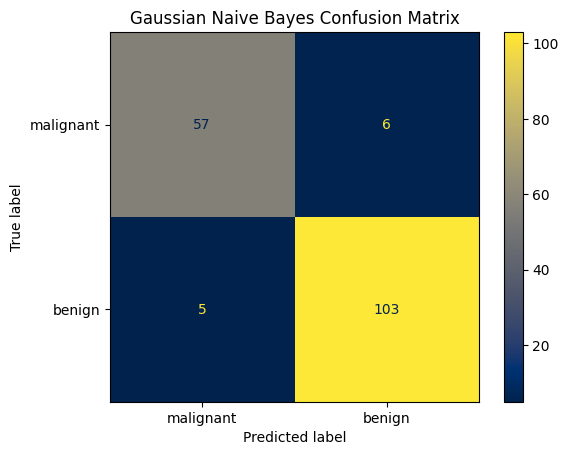

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


<Figure size 800x600 with 0 Axes>

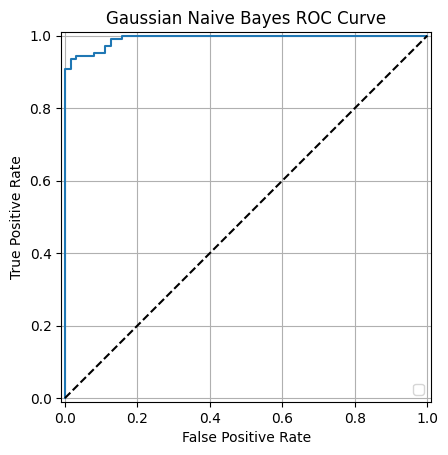

Gaussian Naive Bayes AUC: 0.9927


In [30]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay, roc_curve, classification_report
import matplotlib.pyplot as plt

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
y_proba_nb = nb_model.predict_proba(X_test)[:, 1]

print("\nGaussian Naive Bayes Classifier Report:")
print(classification_report(y_test, y_pred_nb))

cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=data.target_names)
disp_nb.plot(cmap=plt.cm.cividis)
plt.title('Gaussian Naive Bayes Confusion Matrix')
plt.show()

plt.figure(figsize=(8, 6))
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_proba_nb)
roc_display_nb = RocCurveDisplay(fpr=fpr_nb, tpr=tpr_nb).plot()
plt.title('Gaussian Naive Bayes ROC Curve')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.show()
auc_nb = roc_auc_score(y_test, y_proba_nb)
print(f"Gaussian Naive Bayes AUC: {auc_nb:.4f}")

Regresja Logistyczna: AUC 0.9981.
Las Losowy: 0.9966
Naiwny Bayes: 0.9927
KNN:0.9777,
Drzewo Decyzyjne: 0.9438